# Stage 17 Signal-Family Ablation

This notebook runs and reviews validation-only signal-family ablations using the fixed Stage 14 square-root-weighted multiscale fusion recipe. Each ablation removes both raw channels and engineered summary features for the selected signal families.

## Setup

The setup cell resolves the repository root, imports the reusable Stage 17 helpers, and defines the output directory used by the ablation workflow.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.signal_ablation import (
    DEFAULT_STAGE17_OUTPUT_DIR,
    assert_validation_only_stage17_outputs,
    default_stage17_signal_ablation_specs,
    load_stage17_signal_ablation_summary,
    run_stage17_signal_ablation,
    summarize_stage17_signal_ablation,
)
from src.train import TrainConfig

stage17_train_feature_path = repo_root / "data" / "processed" / "features_train.csv"
stage17_validation_feature_path = repo_root / "data" / "processed" / "features_val.csv"
stage17_output_dir = repo_root / DEFAULT_STAGE17_OUTPUT_DIR
stage17_base_config = TrainConfig(
    raw_dir=repo_root / "data" / "raw",
    epoch_index_path=repo_root / "data" / "interim" / "epoch_index.csv",
    preprocessing_metadata_path=(
        repo_root / "data" / "processed" / "preprocessing_metadata.json"
    ),
    participant_array_cache_dir=repo_root / "data" / "processed" / "deep" / "participants",
    train_feature_path=stage17_train_feature_path,
    validation_feature_path=stage17_validation_feature_path,
    feature_preprocessing_metadata_path=(
        repo_root / "data" / "processed" / "feature_preprocessing_metadata.json"
    ),
)
figures_dir = stage17_output_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

## Ablation Design

This cell lists the planned Stage 17 ablations. Signal families are grouped as cardiovascular, movement, electrodermal activity, and temperature. For each run, the helper applies the same family selection to both raw channels and engineered feature columns.

In [2]:
stage17_specs = default_stage17_signal_ablation_specs()
spec_table = pd.DataFrame(
    [
        {
            "ablation_id": spec.name,
            "label": spec.label,
            "included_families": ", ".join(spec.included_families),
            "omitted_families": ", ".join(spec.omitted_families) or "none",
            "description": spec.description,
        }
        for spec in stage17_specs
    ]
)
display(spec_table)

,ablation_id,label,included_families,omitted_families,description
0,full,Full,"cardiovascular, movement, eda, temperature",none,All raw channels and engineered signal-family ...
1,without_cardiovascular,No cardiovascular,"movement, eda, temperature",cardiovascular,"Exclude BVP, HR, and IBI raw channels and engi..."
2,without_movement,No movement,"cardiovascular, eda, temperature",movement,Exclude accelerometer raw channels and enginee...
3,without_eda,No EDA,"cardiovascular, movement, temperature",eda,Exclude EDA raw channel and engineered EDA fea...
4,without_temperature,No temperature,"cardiovascular, movement, eda",temperature,Exclude TEMP raw channel and engineered temper...
5,cardiovascular_only,Cardiovascular only,cardiovascular,"movement, eda, temperature","Use only BVP, HR, and IBI raw channels and eng..."
6,movement_only,Movement only,movement,"cardiovascular, eda, temperature",Use only accelerometer raw channels and engine...
7,eda_only,EDA only,eda,"cardiovascular, movement, temperature",Use only EDA raw channel and engineered EDA fe...
8,temperature_only,Temperature only,temperature,"cardiovascular, movement, eda",Use only TEMP raw channel and engineered tempe...


## Run Or Load Results

The run switch controls whether the Stage 17 ablations are trained. Leave it disabled when reviewing existing artifacts. When enabled, the helper writes ablated feature tables, per-run outputs, and a combined summary under `results/stage17_signal_ablation`. Completed ablations are skipped by default when their saved summary matches the current fixed recipe.

In [ ]:
RUN_STAGE17_SIGNAL_ABLATION = False
SKIP_COMPLETED_ABLATIONS = True
OVERWRITE_ABLATED_FEATURE_TABLES = False

if RUN_STAGE17_SIGNAL_ABLATION:
    missing_inputs = [
        path
        for path in [stage17_train_feature_path, stage17_validation_feature_path]
        if not path.exists()
    ]
    if missing_inputs:
        raise FileNotFoundError(
            "Stage 17 requires engineered train/validation feature tables: "
            f"{missing_inputs}"
        )
    stage17_summary = run_stage17_signal_ablation(
        stage17_specs,
        base_config=stage17_base_config,
        output_dir=stage17_output_dir,
        train_feature_path=stage17_train_feature_path,
        validation_feature_path=stage17_validation_feature_path,
        overwrite_feature_tables=OVERWRITE_ABLATED_FEATURE_TABLES,
        skip_completed=SKIP_COMPLETED_ABLATIONS,
    )
else:
    stage17_summary = load_stage17_signal_ablation_summary(stage17_output_dir)
    if stage17_summary.empty:
        print(
            "No Stage 17 summary found yet. Set RUN_STAGE17_SIGNAL_ABLATION = True "
            "to run the validation-only ablation workflow."
        )

if not stage17_summary.empty:
    assert_validation_only_stage17_outputs(stage17_output_dir)
    stage17_summary = summarize_stage17_signal_ablation(stage17_summary)
    display(stage17_summary)

,stage,ablation_id,ablation_label,stage17_run_status,description,included_families,omitted_families,raw_channels,engineered_feature_columns,n_raw_channels,...,Non_REM_f1,REM_precision,REM_recall,REM_f1,delta_accuracy,delta_balanced_accuracy,delta_macro_f1,delta_Wake_f1,delta_Non_REM_f1,delta_REM_f1
0,stage17,full,Full,trained,All raw channels and engineered signal-family ...,"[""cardiovascular"", ""movement"", ""eda"", ""tempera...",[],"[""BVP"", ""HR"", ""IBI"", ""ACC_X"", ""ACC_Y"", ""ACC_Z""...","[""BVP_mean"", ""BVP_std"", ""BVP_min"", ""BVP_max"", ...",8,...,0.702982,0.236945,0.213934,0.224852,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,stage17,without_cardiovascular,No cardiovascular,trained,"Exclude BVP, HR, and IBI raw channels and engi...","[""movement"", ""eda"", ""temperature""]","[""cardiovascular""]","[""ACC_X"", ""ACC_Y"", ""ACC_Z"", ""EDA"", ""TEMP""]","[""ACC_X_mean"", ""ACC_X_std"", ""ACC_X_min"", ""ACC_...",5,...,0.701889,0.146239,0.195637,0.167369,-0.008980,-0.028315,-0.018567,0.002873,-0.001092,-0.057483
2,stage17,without_movement,No movement,trained,Exclude accelerometer raw channels and enginee...,"[""cardiovascular"", ""eda"", ""temperature""]","[""movement""]","[""BVP"", ""HR"", ""IBI"", ""EDA"", ""TEMP""]","[""BVP_mean"", ""BVP_std"", ""BVP_min"", ""BVP_max"", ...",5,...,0.760825,0.252935,0.166784,0.201018,0.056539,-0.018707,0.002783,-0.025660,0.057843,-0.023834
3,stage17,without_eda,No EDA,trained,Exclude EDA raw channel and engineered EDA fea...,"[""cardiovascular"", ""movement"", ""temperature""]","[""eda""]","[""BVP"", ""HR"", ""IBI"", ""ACC_X"", ""ACC_Y"", ""ACC_Z""...","[""BVP_mean"", ""BVP_std"", ""BVP_min"", ""BVP_max"", ...",7,...,0.706157,0.135163,0.280788,0.182483,-0.016796,-0.043396,-0.025031,-0.035899,0.003176,-0.042369
4,stage17,without_temperature,No temperature,trained,Exclude TEMP raw channel and engineered temper...,"[""cardiovascular"", ""movement"", ""eda""]","[""temperature""]","[""BVP"", ""HR"", ""IBI"", ""ACC_X"", ""ACC_Y"", ""ACC_Z""...","[""BVP_mean"", ""BVP_std"", ""BVP_min"", ""BVP_max"", ...",7,...,0.729084,0.138009,0.257565,0.179720,0.005654,-0.038062,-0.016630,-0.030861,0.026102,-0.045132
5,stage17,cardiovascular_only,Cardiovascular only,trained,"Use only BVP, HR, and IBI raw channels and eng...","[""cardiovascular""]","[""movement"", ""eda"", ""temperature""]","[""BVP"", ""HR"", ""IBI""]","[""BVP_mean"", ""BVP_std"", ""BVP_min"", ""BVP_max"", ...",3,...,0.723192,0.247939,0.275158,0.260841,0.015798,0.003907,0.011164,-0.022708,0.020210,0.035988
6,stage17,movement_only,Movement only,trained,Use only accelerometer raw channels and engine...,"[""movement""]","[""cardiovascular"", ""eda"", ""temperature""]","[""ACC_X"", ""ACC_Y"", ""ACC_Z""]","[""ACC_X_mean"", ""ACC_X_std"", ""ACC_X_min"", ""ACC_...",3,...,0.759032,0.161520,0.143561,0.152012,0.055957,-0.038609,-0.010471,-0.014624,0.056051,-0.072840
7,stage17,eda_only,EDA only,trained,Use only EDA raw channel and engineered EDA fe...,"[""eda""]","[""cardiovascular"", ""movement"", ""temperature""]","[""EDA""]","[""EDA_mean"", ""EDA_std"", ""EDA_min"", ""EDA_max"", ...",1,...,0.780701,0.000000,0.000000,0.000000,0.072670,-0.058460,-0.065501,-0.049372,0.077720,-0.224852
8,stage17,temperature_only,Temperature only,trained,Use only TEMP raw channel and engineered tempe...,"[""temperature""]","[""cardiovascular"", ""movement"", ""eda""]","[""TEMP""]","[""TEMP_mean"", ""TEMP_std"", ""TEMP_min"", ""TEMP_ma...",1,...,0.802954,0.000000,0.000000,0.000000,0.104265,-0.058988,-0.058209,-0.049747,0.099972,-0.224852


## Validation Metric Deltas

This table focuses on the primary validation metrics and their differences from the full signal-family run.

In [4]:
if stage17_summary.empty:
    print("Stage 17 summary is not available yet.")
else:
    metric_columns = [
        "ablation_id",
        "ablation_label",
        "macro_f1",
        "delta_macro_f1",
        "balanced_accuracy",
        "delta_balanced_accuracy",
        "accuracy",
        "delta_accuracy",
    ]
    metric_columns = [column for column in metric_columns if column in stage17_summary.columns]
    metric_table = stage17_summary[metric_columns]
    if "macro_f1" in metric_table.columns:
        metric_table = metric_table.sort_values("macro_f1", ascending=False)
    display(metric_table)

,ablation_id,ablation_label,macro_f1,delta_macro_f1,balanced_accuracy,delta_balanced_accuracy,accuracy,delta_accuracy
5,cardiovascular_only,Cardiovascular only,0.448835,0.011164,0.460335,0.003907,0.592999,0.015798
2,without_movement,No movement,0.440454,0.002783,0.437721,-0.018707,0.633741,0.056539
0,full,Full,0.437671,0.000000,0.456428,0.000000,0.577201,0.000000
6,movement_only,Movement only,0.427200,-0.010471,0.417820,-0.038609,0.633159,0.055957
4,without_temperature,No temperature,0.421041,-0.016630,0.418367,-0.038062,0.582855,0.005654
1,without_cardiovascular,No cardiovascular,0.419104,-0.018567,0.428113,-0.028315,0.568222,-0.008980
3,without_eda,No EDA,0.412640,-0.025031,0.413032,-0.043396,0.560406,-0.016796
8,temperature_only,Temperature only,0.379462,-0.058209,0.397440,-0.058988,0.681467,0.104265
7,eda_only,EDA only,0.372170,-0.065501,0.397968,-0.058460,0.649871,0.072670


## Macro F1 By Ablation

This figure compares validation macro F1 across signal-family ablations and saves the result as `stage17_macro_f1_by_ablation.png`.

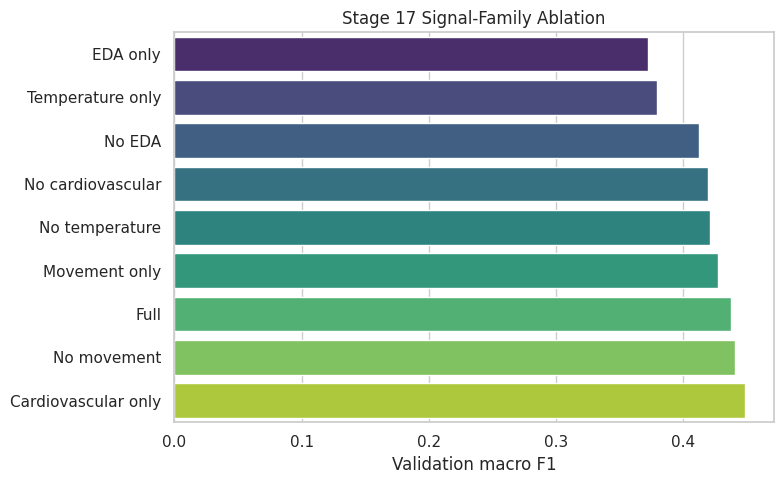

Saved /home/manns79/dreamt-wearable-sleep-staging/results/stage17_signal_ablation/figures/stage17_macro_f1_by_ablation.png


In [5]:
if stage17_summary.empty or "macro_f1" not in stage17_summary.columns:
    print("Macro F1 summary is not available yet.")
else:
    plot_data = stage17_summary.sort_values("macro_f1", ascending=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(
        data=plot_data,
        x="macro_f1",
        y="ablation_label",
        hue="ablation_label",
        dodge=False,
        legend=False,
        palette="viridis",
        ax=ax,
    )
    ax.set_xlabel("Validation macro F1")
    ax.set_ylabel("")
    ax.set_title("Stage 17 Signal-Family Ablation")
    fig.tight_layout()
    output_path = figures_dir / "stage17_macro_f1_by_ablation.png"
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    print(f"Saved {output_path}")

## Metric Drop From Full Recipe

This figure shows validation macro-F1 change relative to the full signal-family recipe and saves the result as `stage17_delta_macro_f1.png`.

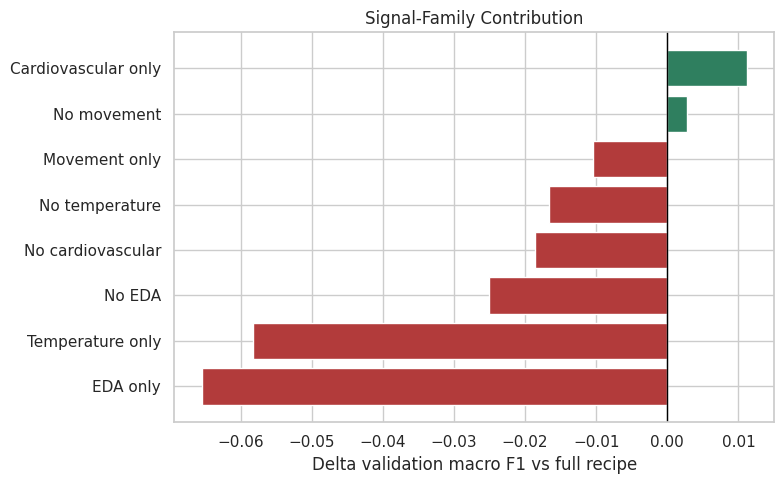

Saved /home/manns79/dreamt-wearable-sleep-staging/results/stage17_signal_ablation/figures/stage17_delta_macro_f1.png


In [6]:
if stage17_summary.empty or "delta_macro_f1" not in stage17_summary.columns:
    print("Delta macro F1 summary is not available yet.")
else:
    plot_data = stage17_summary[stage17_summary["ablation_id"] != "full"].copy()
    plot_data = plot_data.sort_values("delta_macro_f1", ascending=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ["#b23b3b" if value < 0 else "#2f7f5f" for value in plot_data["delta_macro_f1"]]
    ax.barh(plot_data["ablation_label"], plot_data["delta_macro_f1"], color=colors)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("Delta validation macro F1 vs full recipe")
    ax.set_ylabel("")
    ax.set_title("Signal-Family Contribution")
    fig.tight_layout()
    output_path = figures_dir / "stage17_delta_macro_f1.png"
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    print(f"Saved {output_path}")

## Per-Class F1 Deltas

This heatmap shows how each ablation changes class-specific validation F1 relative to the full recipe and saves the result as `stage17_class_f1_deltas.png`.

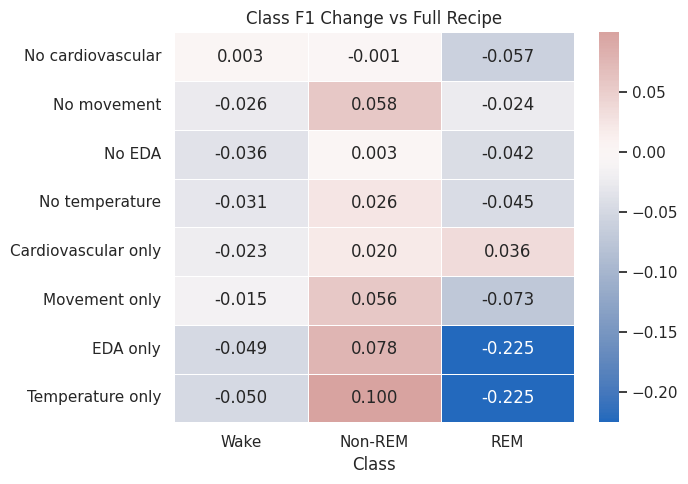

Saved /home/manns79/dreamt-wearable-sleep-staging/results/stage17_signal_ablation/figures/stage17_class_f1_deltas.png


In [7]:
class_delta_columns = ["delta_Wake_f1", "delta_Non_REM_f1", "delta_REM_f1"]
if stage17_summary.empty or not set(class_delta_columns).issubset(stage17_summary.columns):
    print("Class-specific F1 deltas are not available yet.")
else:
    heatmap_data = stage17_summary[stage17_summary["ablation_id"] != "full"].copy()
    heatmap_data = heatmap_data.set_index("ablation_label")[class_delta_columns]
    heatmap_data = heatmap_data.rename(
        columns={
            "delta_Wake_f1": "Wake",
            "delta_Non_REM_f1": "Non-REM",
            "delta_REM_f1": "REM",
        }
    )
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".3f",
        center=0,
        cmap="vlag",
        linewidths=0.5,
        ax=ax,
    )
    ax.set_xlabel("Class")
    ax.set_ylabel("")
    ax.set_title("Class F1 Change vs Full Recipe")
    fig.tight_layout()
    output_path = figures_dir / "stage17_class_f1_deltas.png"
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    print(f"Saved {output_path}")

## Training Curves

This panel reviews validation macro-F1 trajectories for completed ablation runs and saves the result as `stage17_training_curves.png`.

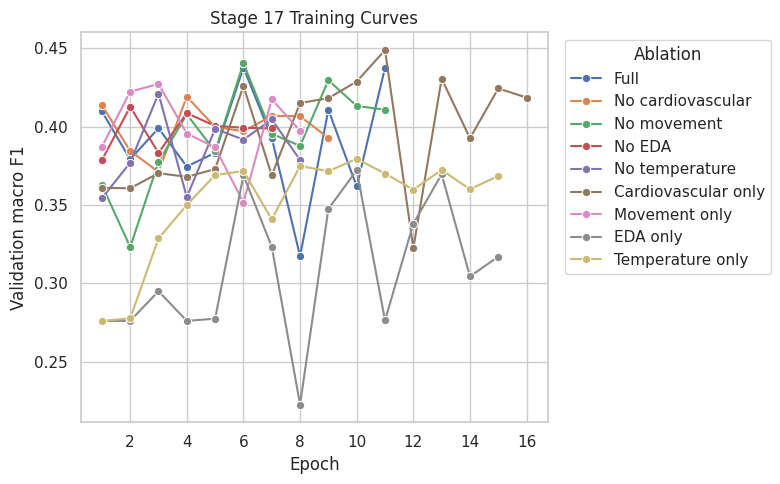

Saved /home/manns79/dreamt-wearable-sleep-staging/results/stage17_signal_ablation/figures/stage17_training_curves.png


In [8]:
history_path = stage17_output_dir / "all_history.csv"
if not history_path.exists():
    print("Stage 17 training history is not available yet.")
else:
    history = pd.read_csv(history_path)
    if history.empty or "macro_f1" not in history.columns:
        print("Stage 17 training history does not contain macro F1 values.")
    else:
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.lineplot(
            data=history,
            x="epoch",
            y="macro_f1",
            hue="ablation_label",
            marker="o",
            ax=ax,
        )
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Validation macro F1")
        ax.set_title("Stage 17 Training Curves")
        ax.legend(title="Ablation", bbox_to_anchor=(1.02, 1), loc="upper left")
        fig.tight_layout()
        output_path = figures_dir / "stage17_training_curves.png"
        fig.savefig(output_path, dpi=180, bbox_inches="tight")
        display(fig)
        plt.close(fig)
        print(f"Saved {output_path}")

## Interpretation Checklist

- Confirm every run completed with the same fixed Stage 14 square-root-weighted recipe except for signal-family inputs.
- Treat leave-one-family-out drops as evidence of incremental family contribution under the fixed recipe.
- Compare family-only runs against leave-one-family-out runs to separate standalone usefulness from complementarity.
- Keep conclusions validation-only until the final frozen model is evaluated once on the held-out test split.